# PXP ScarFinder From `Z_2`

This notebook turns the temporary `ScarFinder` idea into a package-level example.
We start from the `Z_2` product state, apply the new `scarfinder!` workflow in `iTEBD.jl`, and then test whether the refined state shows slower entanglement growth under real-time PXP evolution.

The goal is not to prove that this state is an exact scar. The goal is to show a compact, reproducible workflow for generating a low-entanglement candidate state directly from the package API.

All loop counts below are intentionally conservative so the notebook stays usable as an example.

## Setup

The notebook activates the package environment, loads the new `ScarFinder` interface, and imports `Plots` for visualization.

In [1]:
import Pkg
Pkg.activate("..")

using iTEBD, LinearAlgebra, Plots

default(linewidth=2, legend=:topright, framestyle=:box, size=(900, 300))

  Activating project at `~/Library/CloudStorage/OneDrive-UniversityofLeeds/GitHub/iTEBD.jl`


## Model And Reference States

We use a four-site translation-averaged PXP density,

$$h_{\mathrm{PXP},4} = \frac{1}{2}(\mathrm{PXP}\otimes I + I\otimes \mathrm{PXP}),$$

so it is compatible with a four-site unit cell. The `Z_2` product state is the natural reference state because it is the standard scar initial state for PXP dynamics.

In [10]:
# Local operators for the PXP model.
P = [0 0; 0 1]
X = [0 1; 1 0]
Z = [1 0; 0 -1]

# Three-site PXP term and a four-site translation-averaged density.
PXP = kron(P, X, P)
PXP4 = (kron(PXP, I(2)) + kron(I(2), PXP)) / 2
ZZ = kron(Z, Z)

# Standard Z2 product state on a four-site unit cell.
function z2_state()
    product_iMPS(ComplexF64, [[0, 1], [1, 0], [0, 1], [1, 0]])
end

# Dominant transfer-matrix eigenvalue as a simple fidelity proxy.
fidelity_density(psi_ref::iMPS, psi::iMPS) = maximum(abs2.(eigvals(iTEBD.gtrm(psi_ref, psi))))

# Convenience observable for short-range order diagnostics.
zz_density(psi::iMPS) = 0.5 * (iTEBD.expect(psi, ZZ, 1, 2) + iTEBD.expect(psi, ZZ, 2, 3))

zz_density (generic function with 1 method)

## Initial Diagnostics

Before searching, we inspect the `Z_2` energy density and estimate the reachable energy window using the package helper `energy_span`.

In [11]:
psi_z2 = z2_state()
target_energy = energy_density(psi_z2, PXP4)
emin, emax, _ = energy_span(4, 2, PXP4; dτ=0.05, Nτ=200, maxdim=16)

(;
    z2_energy=target_energy,
    z2_entropy=iTEBD.ent_S(psi_z2, psi_z2.n),
    estimated_energy_window=(emin, emax),
)

(z2_energy = 0.0, z2_entropy = 0.0, estimated_energy_window = (-0.603537374836859, 0.6035373795594041))

## Scar Search Trajectory

The search step alternates:

1. real-time evolution,
2. truncation back to bond dimension `χ`,
3. a small imaginary-time correction that keeps the energy density near the `Z_2` value.

The histories below make it clear whether the search stays near the target energy and whether it is actually reducing the entanglement.

In [12]:
psi_search = z2_state()
search_steps = 500
search_dt = 0.01
chi = 2

energy_hist = zeros(search_steps)
entropy_hist = zeros(search_steps)
fidelity_hist = zeros(search_steps)
zz_hist = zeros(search_steps)

for step in 1:search_steps
    scarfinder_step!(psi_search, PXP4, search_dt, chi;
        nstep=10,
        target=target_energy,
        maxdim=8,
    )
    energy_hist[step] = energy_density(psi_search, PXP4)
    entropy_hist[step] = iTEBD.ent_S(psi_search, psi_search.n)
    fidelity_hist[step] = fidelity_density(psi_z2, psi_search)
    zz_hist[step] = zz_density(psi_search)
end

(;
    final_energy=energy_hist[end],
    final_entropy=entropy_hist[end],
    final_fidelity=fidelity_hist[end],
    final_zz=zz_hist[end],
)

(final_energy = -1.4972582084141192e-14, final_entropy = 0.10539697725924821, final_fidelity = 9.434994541037906e-9, final_zz = -0.8948419387085487)

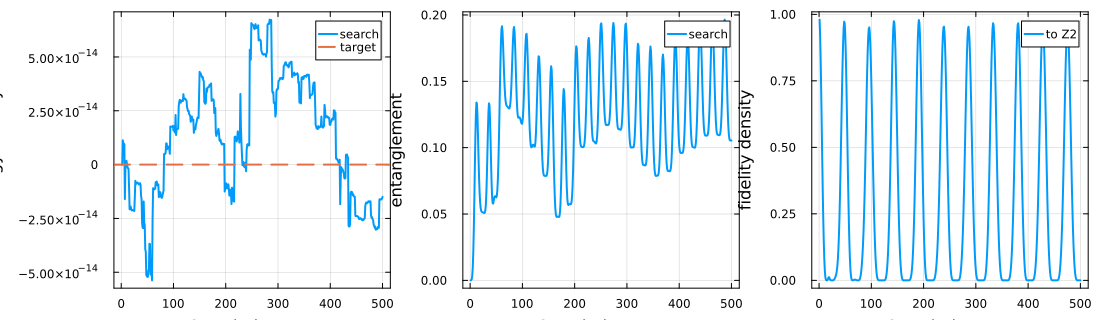

In [13]:
p1 = plot(1:search_steps, energy_hist, xlabel="ScarFinder step", ylabel="energy density", label="search")
hline!(p1, [target_energy], linestyle=:dash, label="target")

p2 = plot(1:search_steps, entropy_hist, xlabel="ScarFinder step", ylabel="entanglement", label="search")

p3 = plot(1:search_steps, fidelity_hist, xlabel="ScarFinder step", ylabel="fidelity density", label="to Z2")

plot(p1, p2, p3; layout=(1, 3), size=(1100, 320))

## Refinement Pass

The full `scarfinder!` helper repeats the search and then scans a shorter-time trajectory to pick the minimum-entanglement point. This mirrors the logic in the temporary `ScarFinder` scripts while keeping the public API compact.

In [14]:
psi_refined = z2_state()

scarfinder!(psi_refined, PXP4, search_dt, chi, search_steps;
    nstep=10,
    target=target_energy,
    maxdim=8,
    refine=true,
    refine_dt=0.01,
    refine_step=4,
)

(;
    refined_energy=energy_density(psi_refined, PXP4),
    refined_entropy=iTEBD.ent_S(psi_refined, psi_refined.n),
    refined_fidelity=fidelity_density(psi_z2, psi_refined),
    refined_zz=zz_density(psi_refined),
)

(refined_energy = -1.5142681934191102e-14, refined_entropy = 0.1053758472508533, refined_fidelity = 1.588488354020264e-8, refined_zz = -0.8415005749256415)

## Real-Time Dynamics From The Refined State

This is the main physics plot. We now compare real-time evolution starting from:

- the original `Z_2` state,
- the refined ScarFinder state.

A useful scar signature is slower entanglement growth together with a relatively structured return in overlap/fidelity.

In [18]:
function time_evolve_pxp(psi0::iMPS; dt::Real=0.05, steps::Integer=200, maxdim::Integer=12)
    gate = exp(-1im * dt * PXP4)
    psi = deepcopy(psi0)

    times = collect(0:steps) .* dt
    entropy = zeros(steps + 1)
    fidelity = zeros(steps + 1)
    energy = zeros(steps + 1)

    entropy[1] = iTEBD.ent_S(psi, psi.n)
    fidelity[1] = fidelity_density(psi0, psi)
    energy[1] = energy_density(psi, PXP4)

    for step in 1:steps
        for site in 1:psi.n
            applygate!(psi, gate, site, mod(site + 3 - 1, psi.n) + 1; maxdim=maxdim)
        end
        entropy[step + 1] = iTEBD.ent_S(psi, psi.n)
        fidelity[step + 1] = fidelity_density(psi0, psi)
        energy[step + 1] = energy_density(psi, PXP4)
    end

    return (; times, entropy, fidelity, energy)
end

time_evolve_pxp (generic function with 1 method)

In [19]:
dyn_z2 = time_evolve_pxp(psi_z2; dt=0.05, steps=200, maxdim=12)
dyn_refined = time_evolve_pxp(psi_refined; dt=0.05, steps=200, maxdim=12)

(times = [0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45  …  9.55, 9.600000000000001, 9.65, 9.700000000000001, 9.75, 9.8, 9.850000000000001, 9.9, 9.950000000000001, 10.0], entropy = [0.1053758472508533, 0.10558219824683725, 0.10610449300497646, 0.10707780291526764, 0.1086485994630035, 0.11095984991762643, 0.11413499809229062, 0.11826101100262673, 0.12337260492530475, 0.12943988144533422  …  0.19247861444472314, 0.1941265191807782, 0.19637039375174134, 0.19931108476261594, 0.20302409819482656, 0.20754915615485095, 0.21288135901941635, 0.21896511709598884, 0.22569179353615607, 0.2329015950103827], fidelity = [0.999999999999996, 0.9974314815417444, 0.9897609967159914, 0.9770930433296277, 0.9595994234003193, 0.9375157657513457, 0.911136783779453, 0.8808103898545304, 0.846930816022793, 0.8099309143528749  …  0.9800686197893282, 0.9673093844839388, 0.949632337109092, 0.9271515907235353, 0.9000461139158636, 0.8685587191558944, 0.83299390935

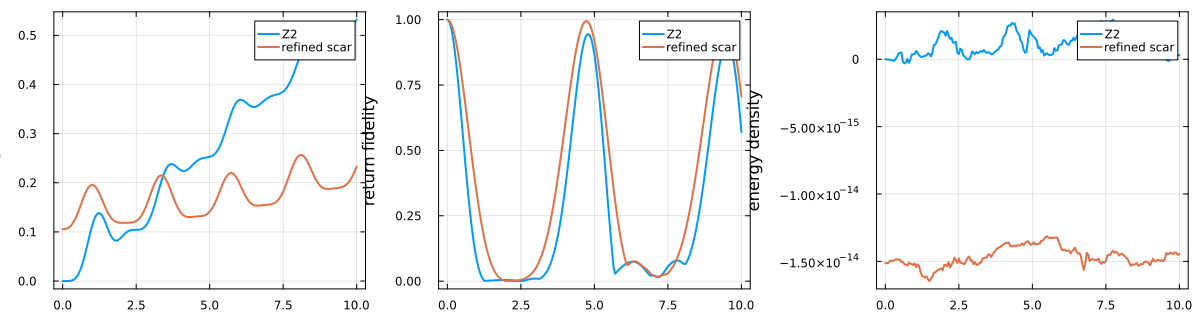

In [20]:
p1 = plot(dyn_z2.times, dyn_z2.entropy, xlabel="time", ylabel="entanglement", label="Z2")
plot!(p1, dyn_refined.times, dyn_refined.entropy, label="refined scar")

p2 = plot(dyn_z2.times, dyn_z2.fidelity, xlabel="time", ylabel="return fidelity", label="Z2")
plot!(p2, dyn_refined.times, dyn_refined.fidelity, label="refined scar")

p3 = plot(dyn_z2.times, dyn_z2.energy, xlabel="time", ylabel="energy density", label="Z2")
plot!(p3, dyn_refined.times, dyn_refined.energy, label="refined scar")

plot(p1, p2, p3; layout=(1, 3), size=(1200, 320))

## Summary

The most important comparison is the dynamics plot above. If the refined state is acting like a useful scar candidate, you should typically see:

- reduced entanglement growth compared with a generic state,
- a more structured fidelity return,
- energy staying close to the target window.

From here, the natural next step is to scan bond dimension `χ`, search time step `dt`, and the target energy choice.